<a href="https://colab.research.google.com/github/QuantLet/CBDC/blob/main/China_test_market_CBDC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import os

# Make the background transparent for saved figures globally
plt.rcParams['savefig.transparent'] = True


In [2]:
output_dir = "./ecny_visuals"
os.makedirs(output_dir, exist_ok=True)
plt.rcParams["figure.dpi"] = 150


# 1. Timeline: From Lab to Live (2014-2026)


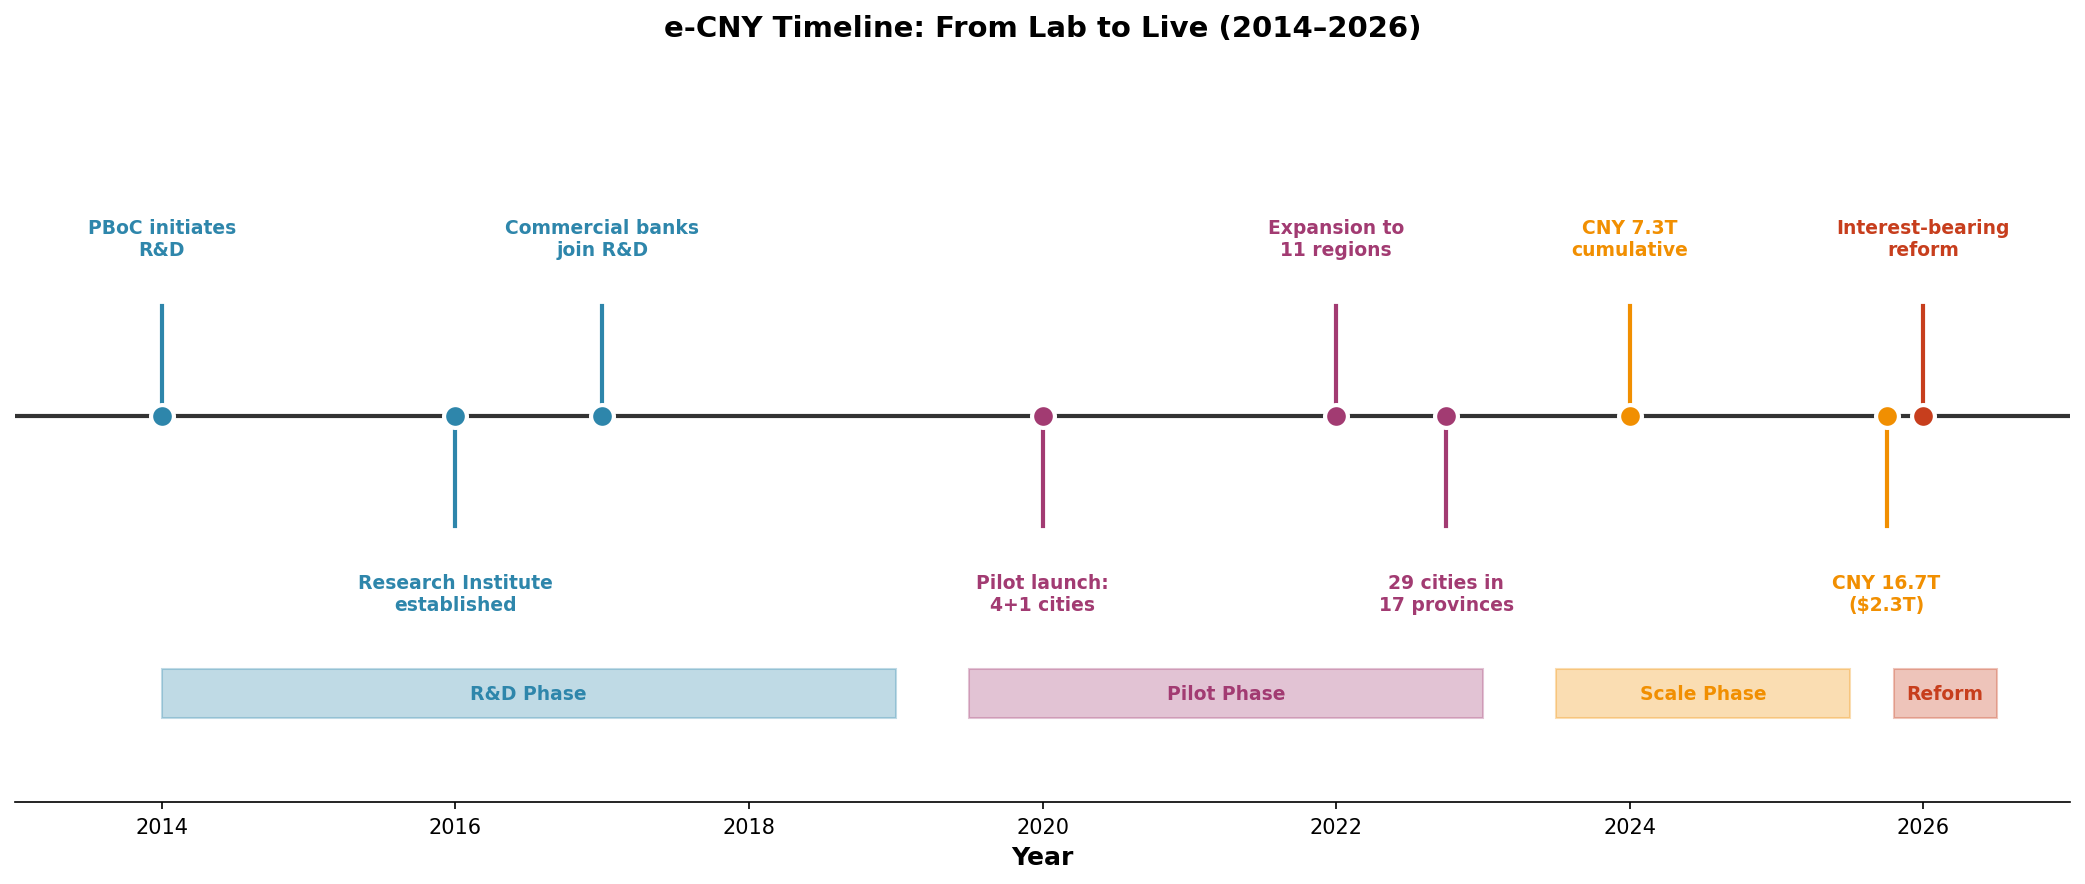

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_alpha(0) # Make the figure background transparent
ax.patch.set_alpha(0) # Make the axes background transparent
events = [
    (2014, "PBoC initiates\nR&D", "R&D"),
    (2016, "Research Institute\nestablished", "R&D"),
    (2017, "Commercial banks\njoin R&D", "R&D"),
    (2020, "Pilot launch:\n4+1 cities", "Pilot"),
    (2022, "Expansion to\n11 regions", "Pilot"),
    (2022.75, "29 cities in\n17 provinces", "Pilot"),
    (2024, "CNY 7.3T\ncumulative", "Scale"),
    (2025.75, "CNY 16.7T\n($2.3T)", "Scale"),
    (2026, "Interest-bearing\nreform", "Reform"),
]
colors = {"R&D": "#2E86AB", "Pilot": "#A23B72", "Scale": "#F18F01", "Reform": "#C73E1D"}
ax.axhline(y=0, color="#333333", linewidth=2, zorder=1)
for i, (year, label, phase) in enumerate(events):
    color = colors[phase]
    above = i % 2 == 0
    y_offset = 1.3 if above else -1.3
    va = "bottom" if above else "top"
    ax.plot([year, year], [0, y_offset * 0.7], color=color, linewidth=2, zorder=2)
    ax.scatter(year, 0, s=120, color=color, zorder=3, edgecolors="white", linewidth=2)
    # Set facecolor to 'none' and edgecolor to 'none' for fully transparent text box backgrounds
    bbox_props = dict(boxstyle="round,pad=0.3", facecolor='none', edgecolor='none')
    ax.text(year, y_offset, label, ha="center", va=va, fontsize=9, bbox=bbox_props, fontweight="bold", color=color)
phases = [(2014, 2019, "R&D Phase", colors["R&D"]), (2019.5, 2023, "Pilot Phase", colors["Pilot"]), (2023.5, 2025.5, "Scale Phase", colors["Scale"]), (2025.8, 2026.5, "Reform", colors["Reform"])]
for start, end, label, color in phases:
    ax.barh(-2.3, end-start, left=start, height=0.4, color=color, alpha=0.3, edgecolor=color)
    # Make the phase label background transparent
    bbox_props_phases = dict(facecolor='none', edgecolor='none')
    ax.text((start+end)/2, -2.3, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold", bbox=bbox_props_phases)
ax.set_xlim(2013, 2027); ax.set_ylim(-3.2, 2.8)
ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_title("e-CNY Timeline: From Lab to Live (2014–2026)", fontsize=14, fontweight="bold", pad=20)
ax.set_yticks([])
for spine in ["top", "right", "left"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(f"{output_dir}/timeline_ecny.png", bbox_inches="tight", dpi=150)
plt.show()

/tmp/ipykernel_1004/2670760399.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11, loc="upper left")


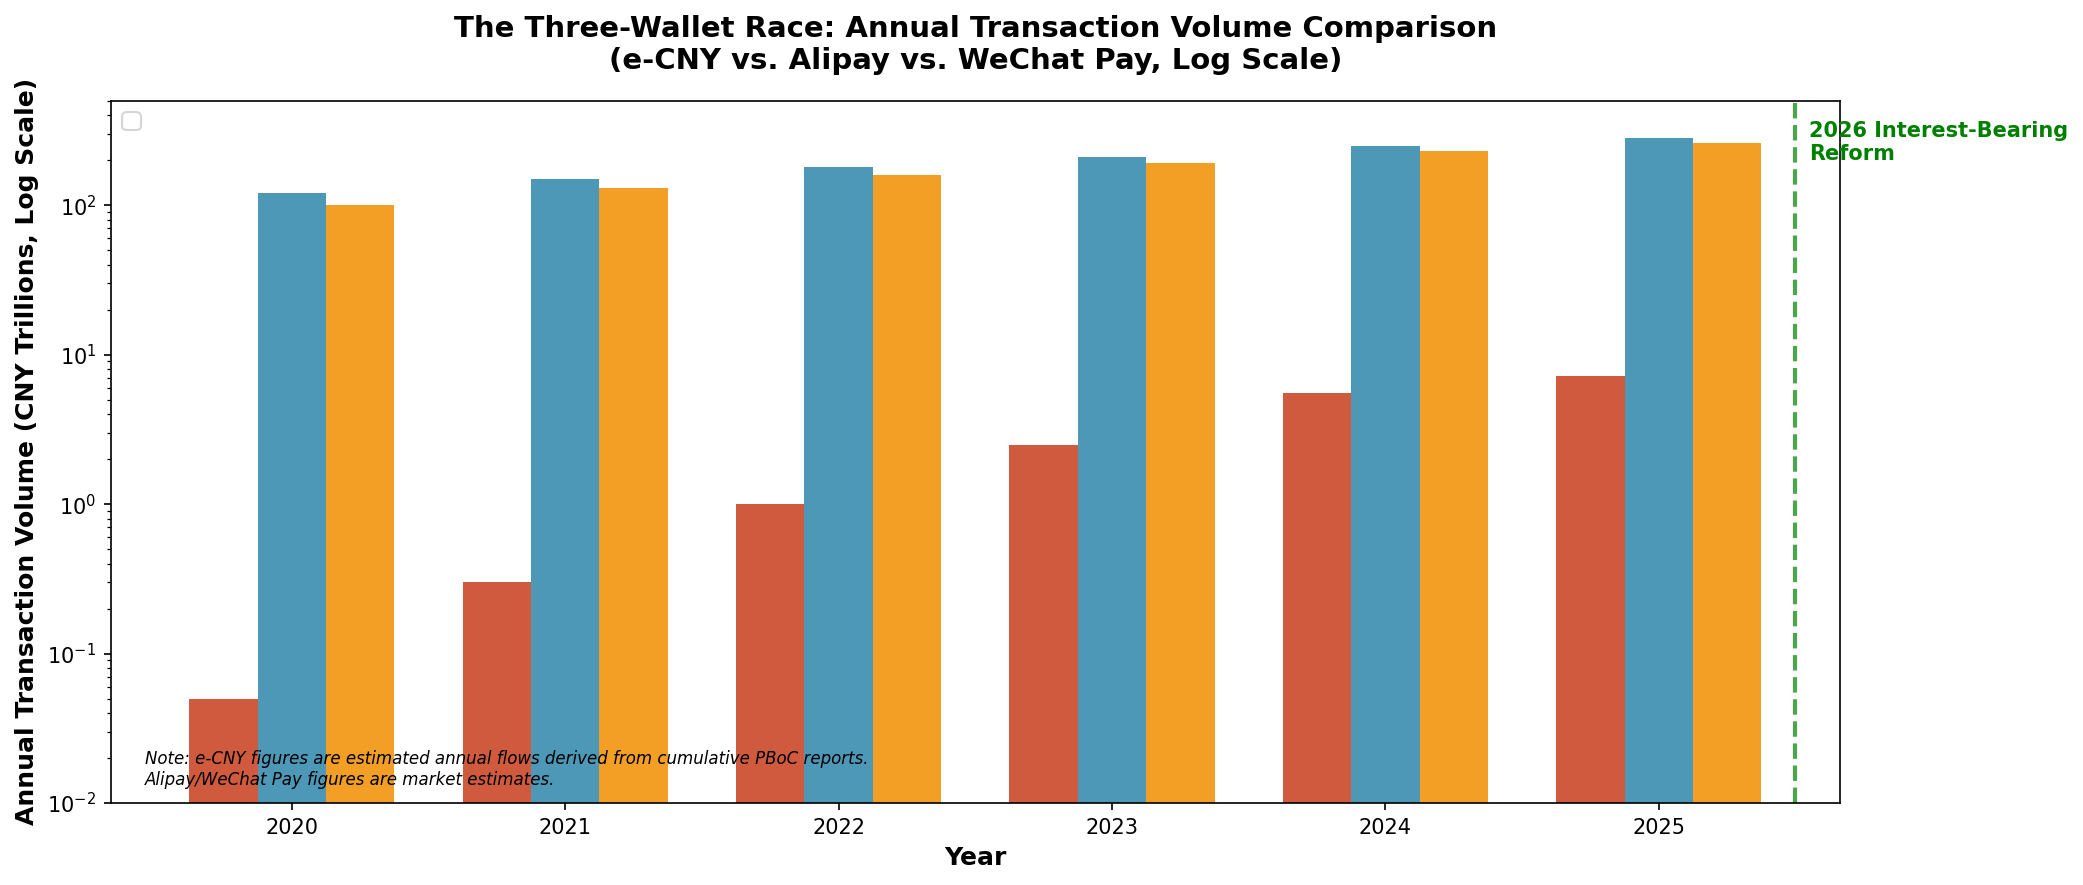

In [4]:
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# 3. LOG-SCALE BAR CHART
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_alpha(0) # Make the figure background transparent
ax.patch.set_alpha(0) # Make the axes background transparent
years = ["2020", "2021", "2022", "2023", "2024", "2025"]
ecny_annual = [0.05, 0.3, 1.0, 2.5, 5.5, 7.2]
alipay_annual = [120, 150, 180, 210, 250, 280]
wechat_annual = [100, 130, 160, 190, 230, 260]
x = np.arange(len(years)); width = 0.25
ax.bar(x - width, ecny_annual, width, color="#C73E1D", alpha=0.85)
ax.bar(x, alipay_annual, width, color="#2E86AB", alpha=0.85)
ax.bar(x + width, wechat_annual, width, color="#F18F01", alpha=0.85)
ax.set_yscale("log")
ax.set_ylabel("Annual Transaction Volume (CNY Trillions, Log Scale)", fontsize=12, fontweight="bold")
ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_title("The Three-Wallet Race: Annual Transaction Volume Comparison\n(e-CNY vs. Alipay vs. WeChat Pay, Log Scale)", fontsize=14, fontweight="bold", pad=15)
ax.set_xticks(x); ax.set_xticklabels(years)
ax.legend(fontsize=11, loc="upper left")
ax.axvline(x=5.5, color="green", linestyle="--", linewidth=2, alpha=0.7)
ax.text(5.55, 200, "2026 Interest-Bearing\nReform", fontsize=10, color="green", fontweight="bold", ha="left")
ax.text(0.02, 0.02, "Note: e-CNY figures are estimated annual flows derived from cumulative PBoC reports.\nAlipay/WeChat Pay figures are market estimates.", transform=ax.transAxes, fontsize=8, verticalalignment="bottom", style="italic")
ax.set_ylim(0.01, 500)
plt.tight_layout()
plt.savefig(f"{output_dir}/log_scale_bar_chart.png", bbox_inches="tight", dpi=150)
plt.show()

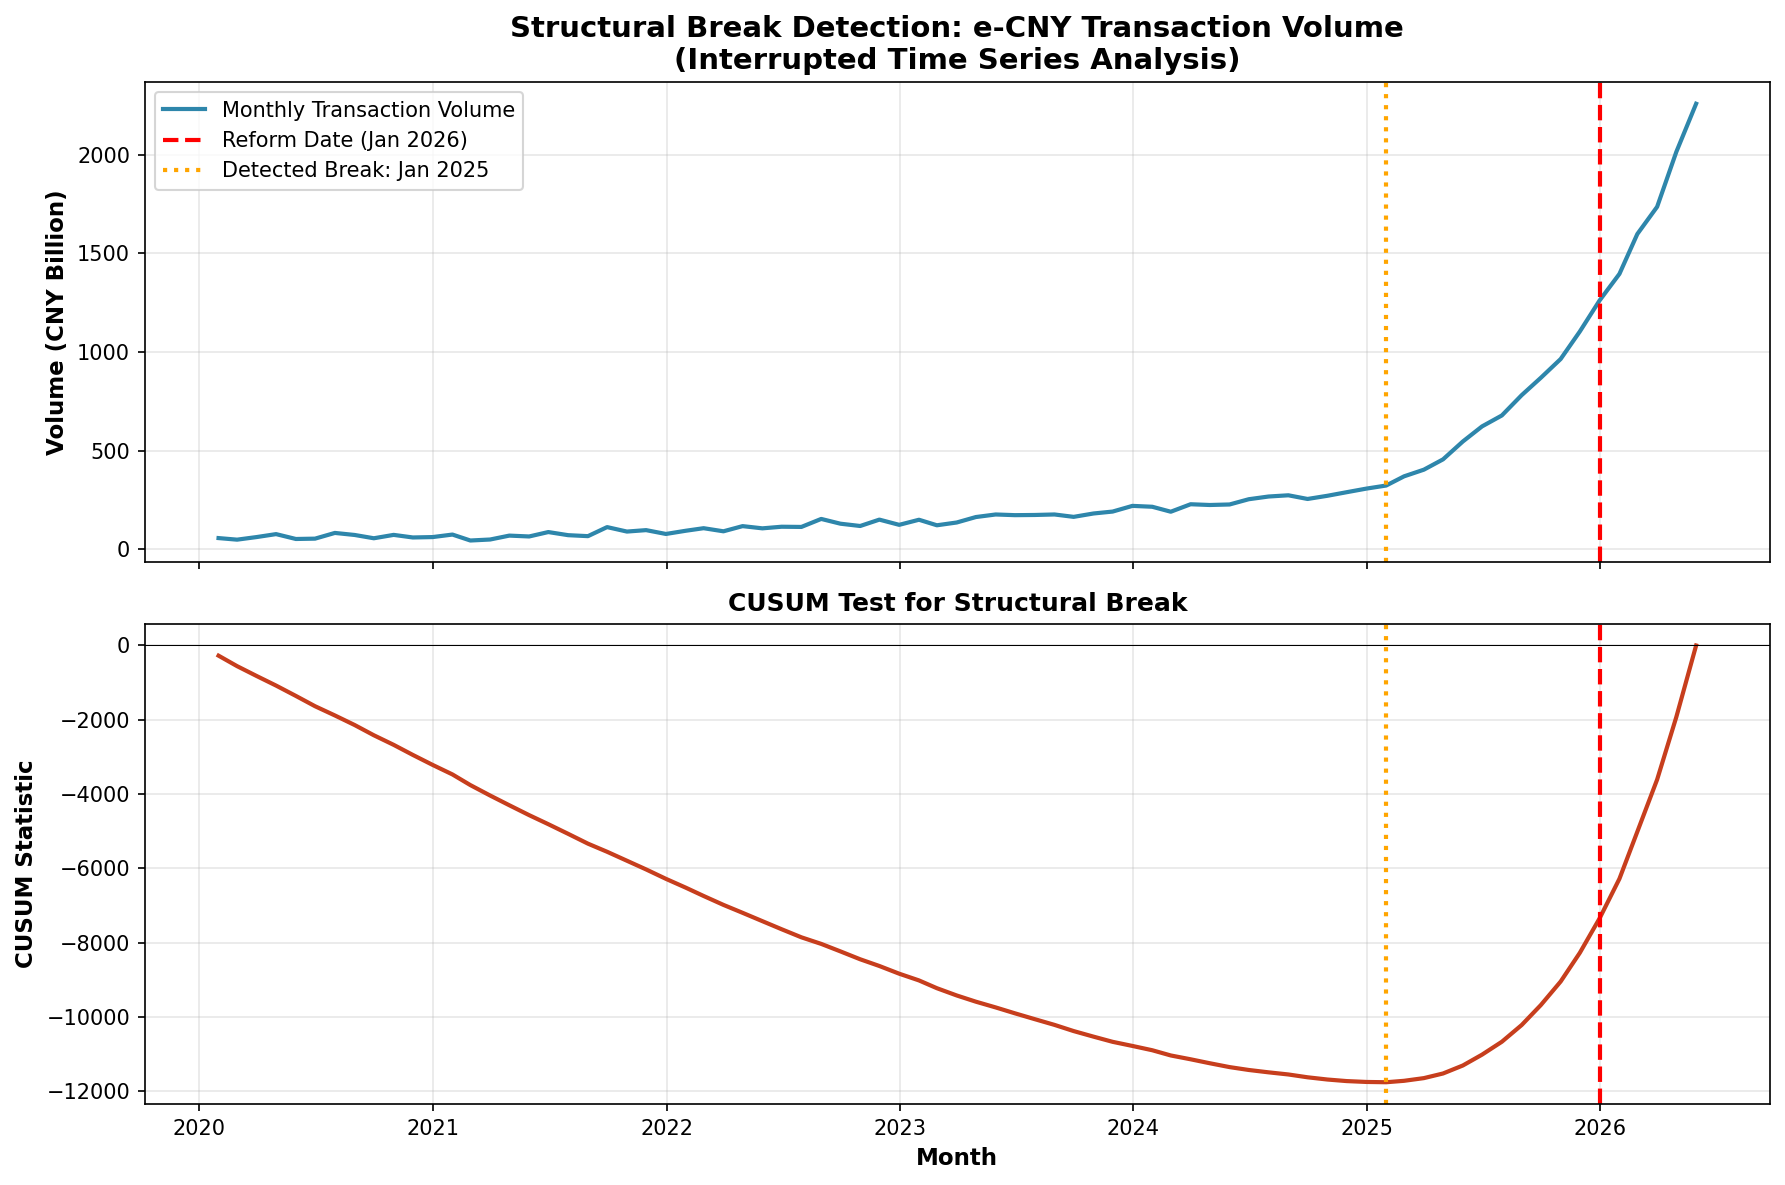

In [5]:
# 4. Demo STRUCTURAL BREAK DETECTION
np.random.seed(42)
months = pd.date_range("2020-01", "2026-06", freq="ME")
n = len(months); t = np.arange(n)
pre_trend = 50 * np.exp(0.03 * t[:60])
post_trend = pre_trend[-1] * np.exp(0.12 * (t[60:] - 59))
noise = np.random.normal(0, 15, n)
y = np.concatenate([pre_trend, post_trend]) + noise
df_break = pd.DataFrame({"month": months, "volume": y})
mean_total = y.mean()
cusum = np.cumsum(y - mean_total)
bp_idx = np.argmax(np.abs(cusum))
breakpoint_date = df_break.iloc[bp_idx]["month"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.patch.set_alpha(0)
axes[0].patch.set_alpha(0)
axes[1].patch.set_alpha(0)
axes[0].plot(df_break["month"], df_break["volume"], color="#2E86AB", linewidth=2, label="Monthly Transaction Volume")
axes[0].axvline(x=pd.Timestamp("2026-01-01"), color="red", linestyle="--", linewidth=2, label="Reform Date (Jan 2026)")
axes[0].axvline(x=breakpoint_date, color="orange", linestyle=":", linewidth=2, label=f"Detected Break: {breakpoint_date.strftime('%b %Y')}")
axes[0].set_ylabel("Volume (CNY Billion)", fontsize=11, fontweight="bold")
axes[0].set_title("Structural Break Detection: e-CNY Transaction Volume\n(Interrupted Time Series Analysis)", fontsize=14, fontweight="bold")
axes[0].legend(loc="upper left"); axes[0].grid(True, alpha=0.3)
axes[1].plot(df_break["month"], cusum, color="#C73E1D", linewidth=2)
axes[1].axvline(x=pd.Timestamp("2026-01-01"), color="red", linestyle="--", linewidth=2)
axes[1].axvline(x=breakpoint_date, color="orange", linestyle=":", linewidth=2)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_ylabel("CUSUM Statistic", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Month", fontsize=11, fontweight="bold")
axes[1].set_title("CUSUM Test for Structural Break", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/structural_break_detection.png", bbox_inches="tight", dpi=150)
plt.show()

Full trajectories plot saved!
Spaghetti plot saved!


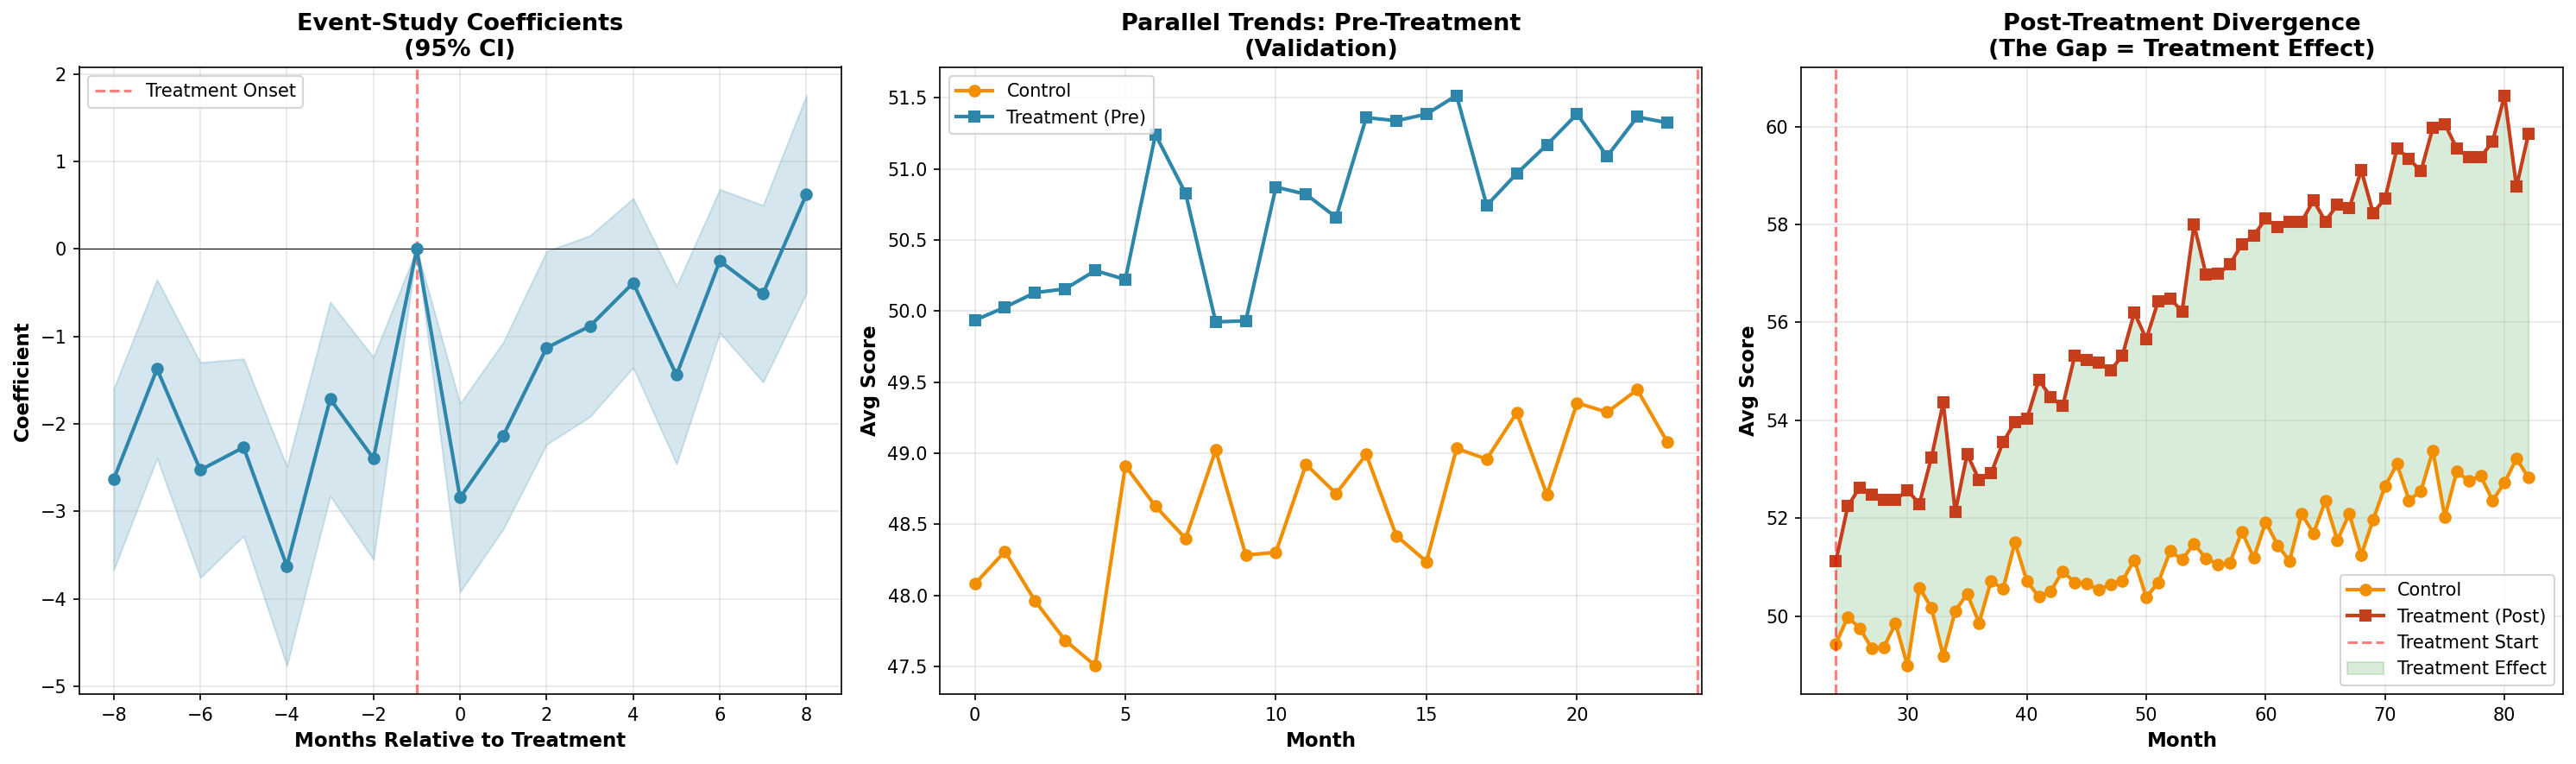

Complete DiD analysis plot saved!

DiD Treatment Effect: 3.5273 (SE: 0.1309)
All files saved to: output
Files: ['structural_break_detection.png', 'did_spaghetti_plot.png', 'did_complete_analysis.png', 'log_scale_bar_chart.png', 'did_full_trajectories.png']


In [6]:
# Demo DID
np.random.seed(123)

n_cities = 100
n_periods = 84
dates = pd.date_range("2019-01", "2025-12", freq="ME")

cities_data = pd.DataFrame({
    "city_id": range(n_cities),
    "treatment": np.random.binomial(1, 0.4, n_cities),
    "treatment_time": np.random.choice([24, 36, 48], n_cities)
})
cities_data.loc[cities_data["treatment"] == 0, "treatment_time"] = 999

panel_data = []
for _, row in cities_data.iterrows():
    city_id = row["city_id"]
    treat = row["treatment"]
    treat_time = row["treatment_time"]
    base_score = np.random.normal(50, 10)
    trend = np.linspace(0, 5, n_periods)

    for t, date in enumerate(dates):
        effect = 0
        if treat == 1 and t >= treat_time:
            # Gradual treatment effect that increases over time
            effect = 5 * (1 - np.exp(-0.1 * (t - treat_time)))
        score = base_score + trend[t] + effect + np.random.normal(0, 3)
        panel_data.append({
            "city_id": city_id,
            "month": date,
            "financial_inclusion": score,
            "treatment": treat,
            "post": 1 if (treat == 1 and t >= treat_time) else 0,
            "time_to_treat": t - treat_time if treat == 1 else -999,
            "period": t
        })

df_did = pd.DataFrame(panel_data)

# PLOT 1: Full Trajectories (Pre + Post Treatment)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_alpha(0)
axes[0].patch.set_alpha(0)
axes[1].patch.set_alpha(0)

# Left panel: Average trajectories by treatment group
monthly_avg = df_did.groupby(['month', 'treatment'])['financial_inclusion'].mean().reset_index()
control_avg = monthly_avg[monthly_avg['treatment'] == 0]
treat_avg = monthly_avg[monthly_avg['treatment'] == 1]

axes[0].plot(control_avg['month'], control_avg['financial_inclusion'],
             'o-', color='#F18F01', linewidth=2, markersize=4, label='Control Cities', alpha=0.8)
axes[0].plot(treat_avg['month'], treat_avg['financial_inclusion'],
             's-', color='#2E86AB', linewidth=2, markersize=4, label='Treatment Cities', alpha=0.8)

# Mark treatment onset (first treatment at period 24 = Jan 2021)
first_treat_date = dates[24]
axes[0].axvline(x=first_treat_date, color='red', linestyle='--', linewidth=2, alpha=0.7, label='First Treatment Onset')

# Shade post-treatment region
axes[0].axvspan(first_treat_date, dates[-1], alpha=0.1, color='red', label='Post-Treatment Period')

axes[0].set_xlabel("Month", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Avg Financial Inclusion Score", fontsize=12, fontweight='bold')
axes[0].set_title("Full Trajectories: Control vs Treatment Cities\n(Pre + Post Treatment)", fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right panel: Treatment Effect Over Time (Dynamic ATT)
# Calculate the gap between treatment and control at each period
period_avg = df_did.groupby(['period', 'treatment'])['financial_inclusion'].mean().reset_index()
pivot_period = period_avg.pivot(index='period', columns='treatment', values='financial_inclusion')
pivot_period['treatment_effect'] = pivot_period[1] - pivot_period[0]

axes[1].axvline(x=24, color='red', linestyle='--', linewidth=2, alpha=0.7, label='First Treatment Onset')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].plot(pivot_period.index, pivot_period['treatment_effect'],
             'o-', color='#C73E1D', linewidth=2, markersize=4, label='Treatment Effect (T - C)')
axes[1].axvspan(24, n_periods-1, alpha=0.1, color='red')

axes[1].set_xlabel("Month (since 2019-01)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Treatment Effect (Score Difference)", fontsize=12, fontweight='bold')
axes[1].set_title("Dynamic Treatment Effect Over Time\n(Average Treatment Effect on the Treated)", fontsize=14, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/did_full_trajectories.png", bbox_inches='tight', dpi=150)
plt.close()
print("Full trajectories plot saved!")

# PLOT 2: Individual City Trajectories (Spaghetti Plot)

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

# Sample 10 control and 10 treatment cities for clarity
sample_control = df_did[df_did['treatment'] == 0]['city_id'].unique()[:10]
sample_treat = df_did[df_did['treatment'] == 1]['city_id'].unique()[:10]

for cid in sample_control:
    city_data = df_did[(df_did['city_id'] == cid) & (df_did['treatment'] == 0)]
    ax.plot(city_data['month'], city_data['financial_inclusion'],
            color='#F18F01', alpha=0.3, linewidth=0.8)

for cid in sample_treat:
    city_data = df_did[(df_did['city_id'] == cid) & (df_did['treatment'] == 1)]
    # Find treatment time for this city
    treat_time = city_data[city_data['post'] == 1]['month'].min()
    pre_data = city_data[city_data['month'] < treat_time]
    post_data = city_data[city_data['month'] >= treat_time]

    ax.plot(pre_data['month'], pre_data['financial_inclusion'],
            color='#2E86AB', alpha=0.3, linewidth=0.8)
    ax.plot(post_data['month'], post_data['financial_inclusion'],
            color='#C73E1D', alpha=0.5, linewidth=1.2)

# Add mean lines
control_mean = df_did[df_did['treatment'] == 0].groupby('month')['financial_inclusion'].mean()
treat_mean = df_did[df_did['treatment'] == 1].groupby('month')['financial_inclusion'].mean()

ax.plot(control_mean.index, control_mean.values, color='#F18F01', linewidth=3, label='Control Mean')
ax.plot(treat_mean.index, treat_mean.values, color='#2E86AB', linewidth=3, label='Treatment Mean')

ax.axvline(x=dates[24], color='red', linestyle='--', linewidth=2, alpha=0.7, label='First Treatment')
ax.axvspan(dates[24], dates[-1], alpha=0.08, color='red')

ax.set_xlabel("Month", fontsize=12, fontweight='bold')
ax.set_ylabel("Financial Inclusion Score", fontsize=12, fontweight='bold')
ax.set_title("Spaghetti Plot: Individual City Trajectories\n(10 Control + 10 Treatment Cities)", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/did_spaghetti_plot.png", bbox_inches='tight', dpi=150)
plt.close()
print("Spaghetti plot saved!")

# PLOT 3: Event Study + Parallel Trends (Enhanced)

df_did_reset = df_did.copy()
df_did_reset["city_id"] = df_did_reset["city_id"].astype("category")
df_did_reset["period"] = df_did_reset["period"].astype("category")

model = smf.ols("financial_inclusion ~ post + C(city_id) + C(period)", data=df_did_reset)
result = model.fit(cov_type="cluster", cov_kwds={"groups": df_did_reset["city_id"]})
did_coef = result.params["post"]
did_se = result.bse["post"]

event_window = list(range(-8, 9))
for tau in event_window:
    mask = (df_did_reset["time_to_treat"] == tau) & (df_did_reset["treatment"] == 1)
    var_name = f"event_{tau}" if tau >= 0 else f"event_neg{abs(tau)}"
    df_did_reset[var_name] = mask.astype(int)

event_vars = [f"event_{tau}" if tau >= 0 else f"event_neg{abs(tau)}" for tau in event_window if tau != -1]
formula_es = "financial_inclusion ~ " + " + ".join(event_vars) + " + C(city_id) + C(period)"
model_es = smf.ols(formula_es, data=df_did_reset)
result_es = model_es.fit(cov_type="cluster", cov_kwds={"groups": df_did_reset["city_id"]})

event_df = pd.DataFrame([{"tau": -1, "coef": 0, "se": 0}])
for tau in event_window:
    if tau != -1:
        var_name = f"event_{tau}" if tau >= 0 else f"event_neg{abs(tau)}"
        coef = result_es.params[var_name]
        se = result_es.bse[var_name]
        event_df = pd.concat([event_df, pd.DataFrame([{"tau": tau, "coef": coef, "se": se}])], ignore_index=True)

event_df = event_df.sort_values("tau")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_alpha(0)
axes[0].patch.set_alpha(0)
axes[1].patch.set_alpha(0)
axes[2].patch.set_alpha(0)

# Panel 1: Event Study Coefficients
axes[0].axvline(x=-1, color="red", linestyle="--", alpha=0.5, label='Treatment Onset')
axes[0].axhline(y=0, color="black", linewidth=0.5)
axes[0].plot(event_df["tau"], event_df["coef"], "o-", color="#2E86AB", linewidth=2, markersize=6)
axes[0].fill_between(event_df["tau"],
                      event_df["coef"] - 1.96*event_df["se"],
                      event_df["coef"] + 1.96*event_df["se"],
                      alpha=0.2, color="#2E86AB")
axes[0].set_xlabel("Months Relative to Treatment", fontsize=11, fontweight='bold')
axes[0].set_ylabel("Coefficient", fontsize=11, fontweight='bold')
axes[0].set_title("Event-Study Coefficients\n(95% CI)", fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel 2: Parallel Trends (Pre-Treatment Only)
pre_trends = df_did[df_did["period"] < 24].groupby(["period", "treatment"])["financial_inclusion"].mean().reset_index()
pivot_trends = pre_trends.pivot(index="period", columns="treatment", values="financial_inclusion")
axes[1].plot(pivot_trends.index, pivot_trends[0], "o-", label="Control", color="#F18F01", linewidth=2)
axes[1].plot(pivot_trends.index, pivot_trends[1], "s-", label="Treatment (Pre)", color="#2E86AB", linewidth=2)
axes[1].axvline(x=24, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Month", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Avg Score", fontsize=11, fontweight='bold')
axes[1].set_title("Parallel Trends: Pre-Treatment\n(Validation)", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: Post-Treatment Divergence
post_trends = df_did[df_did["period"] >= 24].groupby(["period", "treatment"])["financial_inclusion"].mean().reset_index()
post_pivot = post_trends.pivot(index="period", columns="treatment", values="financial_inclusion")
axes[2].plot(post_pivot.index, post_pivot[0], "o-", label="Control", color="#F18F01", linewidth=2)
axes[2].plot(post_pivot.index, post_pivot[1], "s-", label="Treatment (Post)", color="#C73E1D", linewidth=2)
axes[2].axvline(x=24, color="red", linestyle="--", alpha=0.5, label='Treatment Start')
axes[2].fill_between(post_pivot.index, post_pivot[0], post_pivot[1],
                      alpha=0.15, color='green', label='Treatment Effect')
axes[2].set_xlabel("Month", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Avg Score", fontsize=11, fontweight='bold')
axes[2].set_title("Post-Treatment Divergence\n(The Gap = Treatment Effect)", fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{output_dir}/did_complete_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("Complete DiD analysis plot saved!")

print(f"\nDiD Treatment Effect: {did_coef:.4f} (SE: {did_se:.4f})")
print(f"All files saved to: {output_dir}")
print(f"Files: {os.listdir(output_dir)}")